In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma
from collections import defaultdict

# Set OpenBLAS to single thread to avoid memory conflicts
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

In [78]:
import importlib

import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [79]:
path = 'Data/20251001/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum_registered'],
    'day2': ['0_fused_zillum_registered'],
    'day2p5': ['0_fused_zillum_registered'],
    'day3': ['0_fused_zillum_registered'],
    'day3p5': ['0_fused_zillum_registered'],
    'day4': ['0_fused_zillum_registered'],
    'day4p5': ['0_fused_zillum_registered'],
    'day4p5-more': ['0_fused_zillum_registered'],
}



times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [80]:
annotation_names = {
    'lgr': '0.C02.percentile99_class',
    'chroma': '0.C03.percentile99_class',
    'cycd': '0.C04.percentile99_class',
    'muc': '1.C03.percentile99_class',
    'aldob': '1.C04.percentile99_class',
    'gluc': '2.C02.percentile99_class',
    'cyca': '2.C03.percentile99_class',
    'agr': '2.C04.percentile99_class',
    'sero': '3.C02.percentile99_class',
    'lyz': '3.C03.percentile99_class',
}

# state an order 
correct_order = list(annotation_names.keys())

In [81]:
res = np.load('sim/vocab_mean_removed.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scalar'].item() 
sigma = res['sigma']
ts = res['ts']

def load_bof(save_path): 
    m = FateMarkers()
    m.load_results(save_path)
    frac = m.compute_recon_quality()
    hks = m.compute_hks_for_new_times(ts, coeffs=False)
    hks_scaled = hks - hks[:, -1][:, np.newaxis] 
    dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
    encoding = np.exp(-dist**2 / (2 * sigma**2))
    coeffs_hks = m.eigvecs.T @ (m.mass_matrix @ encoding)
    return m.coeffs_fm[:], coeffs_hks, frac

def load(save_path, ts):
    m = FateMarkers()
    m.load_results(save_path)
    frac = m.compute_recon_quality()
    hks_coeffs = m.compute_hks_for_new_times(ts) 
    A = m.mass_matrix.diagonal().sum()
    indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 
    return m.coeffs_fm[:, indices], hks_coeffs, frac, A 

In [82]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = []
areas = [] 

ts = [1, 4, 25, 100]


for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]
        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                c1, c2, frac, A  = load(save_path, ts)
                coeffs_fm.append(c1)
                coeffs_hks.append(c2)
                times.append(timepoint[3:6])
                fracs.append(frac)
                areas.append(A)

100%|██████████| 60/60 [00:03<00:00, 15.56it/s]


In [83]:
threshold = np.percentile(fracs, 99)
recon_mask = np.array(fracs) < threshold
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]
filtered_areas = np.array(areas)[recon_mask]
coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]

In [84]:
coeffs = np.concatenate([np.array(coeffs_fm_filtered), filtered_hks], axis=-1)

hks_names = [f'hks-{ts[i]}' for i in range(filtered_hks.shape[-1])]
names = correct_order + hks_names 
print(names)

['lgr', 'chroma', 'cycd', 'muc', 'aldob', 'gluc', 'cyca', 'agr', 'sero', 'lyz', 'hks-1', 'hks-4', 'hks-25', 'hks-100']


In [71]:
import math

def plot_matrices(matrices, title='Mutual Information', cmap='viridis'): 

    # Loop over all matrices for each timepoint
    unique_times_list = np.unique(times)
    n_timepoints = len(unique_times_list)

    short_names = names 

    # Calculate number of rows needed for 2 columns
    n_cols = 4
    n_rows = math.ceil(n_timepoints / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()  # Flatten in case axes is 2D

    if cmap == 'PiYG' or cmap == 'bwr': 
        vmax = max(np.max(matrices), -np.min(matrices))
        vmin = -vmax
    if cmap == 'viridis': 
        vmin = None
        vmax = None

    for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
        n_features = mi_matrix.shape[0]
        
        # Plot 2: Without diagonal elements
        mask = np.eye(n_features, dtype=bool)
        mi_matrix_masked = np.copy(mi_matrix)
        mi_matrix_masked[mask] = np.nan

        im2 = axes[idx].imshow(mi_matrix_masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        plt.colorbar(im2, ax=axes[idx], label=f'{title}')
        axes[idx].set_xticks(ticks=np.arange(n_features))
        axes[idx].set_xticklabels(short_names, rotation=90, ha='right')
        axes[idx].set_yticks(ticks=np.arange(n_features))
        axes[idx].set_yticklabels(short_names)
        axes[idx].set_title(f'{title} (no diagonal) - Day {timepoint}')

    # Hide any unused subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [44]:
ksg = KSGEstimator()

coeffs_rescaled = np.empty_like(coeffs) 

for i in range(coeffs.shape[-1]):
    scaler = StandardScaler()
    coeffs_rescaled[:, :, i] = scaler.fit_transform(coeffs[:, :, i])

mi_matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    mi_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs_rescaled[mask, :, :] 
    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 

            X = np.copy(masked_coeffs[:, :, i])
            Y = np.copy(masked_coeffs[:, :, j])
            mi_matrix[i, j] = ksg.mutual_information(X, Y, method=2)
    mi_matrices.append(mi_matrix)


41 1p5
30 2
41 2p5
47 3
35 3p5
36 4
57 4p5


In [131]:
np.savez('sim/fm_coeffs_wo_encoding.npz', 
         filtered_time=filtered_times,
         coeffs=coeffs, 
         names=names, 
         mi=np.array(matrices)
         )

np.save('sim/mi.npy', np.array(matrices))


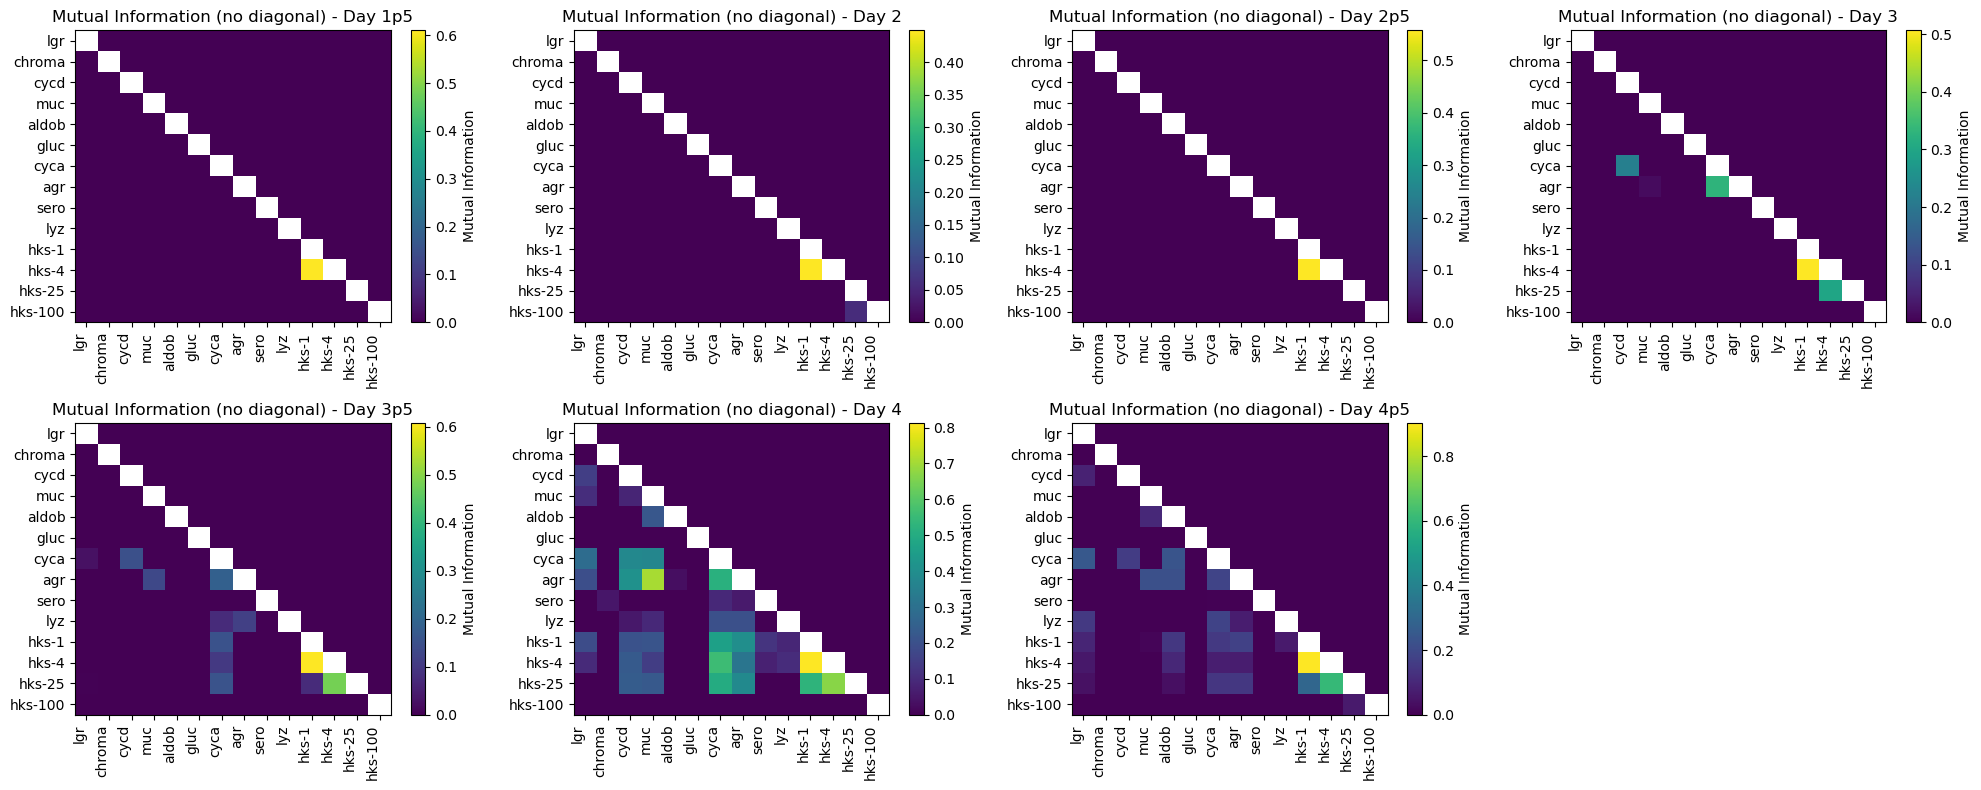

In [45]:
plot_matrices(mi_matrices)

In [ ]:
def compute_corr(X, Y, A):
    # X shape: (n_samples, n_coefficients)
    corr = np.sum(np.sum(X * Y, axis=1)/A)/X.shape[0]
    x_var = np.sum(np.sum(X * X, axis=1)/A)/X.shape[0] 
    y_var = np.sum(np.sum(Y * Y, axis=1)/A)/X.shape[0] 
    return corr, x_var, y_var

In [105]:
corr_matrices = [] 


vars = np.sum(coeffs[:, 1:]*coeffs[:, 1:], axis=1)/filtered_areas[:, np.newaxis]
vars = np.sum(vars, axis=0)/vars.shape[0]

print(vars.shape) 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    corr_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs[mask, :, :] 


    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 
            X = np.copy(masked_coeffs[:, 1:, i])
            Y = np.copy(masked_coeffs[:, 1:, j])
            corr, x_var, y_var = compute_corr(X, Y, filtered_areas[mask])
            if x_var < 1e-10 or y_var < 1e-10: 
                corr_matrix[i, j] = 0
            else:
                corr_matrix[i, j] = corr / np.sqrt(x_var * y_var)
                corr_matrix[j, i] = corr_matrix[i, j]
    corr_matrices.append(corr_matrix)

(14,)
378 1p5
280 2
369 2p5
472 3
311 3p5
349 4
621 4p5


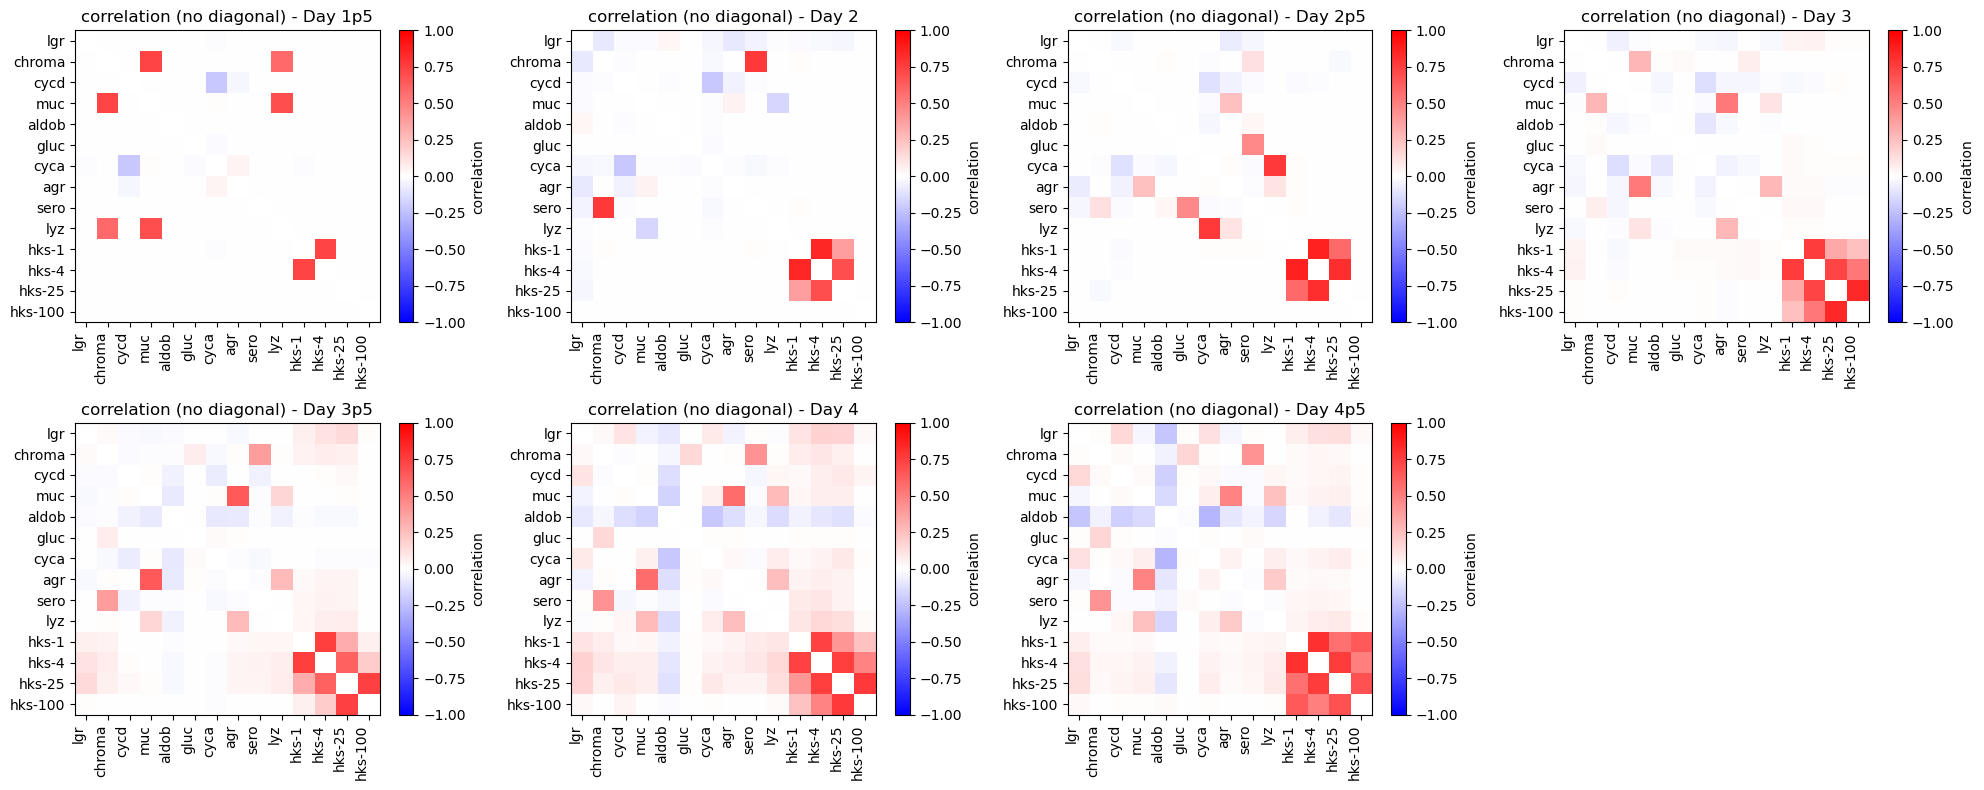

In [106]:
plot_matrices(corr_matrices, title='correlation', cmap='bwr')